# ========== PRÁCTICA 3 : PROCESSAMENT D'IMATGES ============

# Inpainting

18/12/2025

Andrés Río Nogués

# Creación de la imagen con parches vacios

Usamos el código de la práctica para crear al imagen con huecos sin información y su máscara para saber donde hay y donde no hay información

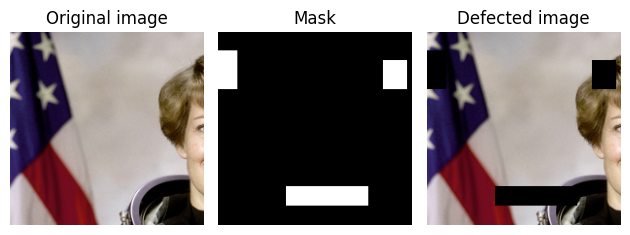

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
mask_rgb=[0,0,0]
image_orig = data.astronaut()[0:200,0:200]
pad_size = 60
# Create mask with three defect regions: left, middle, right respectively
mask = np.zeros(image_orig.shape[:-1])
mask[20:60, 0:20] = 1
mask[160:180, 70:155] = 1
mask[30:60, 170:195] = 1
# Defect image over the same region in each color channel
image_defect = image_orig.copy()
for layer in range(image_defect.shape[-1]):
 image_defect[np.where(mask)] = mask_rgb

fig, axes = plt.subplots(ncols=3, nrows=1)
ax = axes.ravel()

ax[0].set_title('Original image')
ax[0].imshow(image_orig)

ax[1].set_title('Mask')
ax[1].imshow(mask, cmap=plt.cm.gray)

ax[2].set_title('Defected image')
ax[2].imshow(image_defect)

for a in ax:
    a.axis('off')

fig.tight_layout()
plt.show()

# Metodos auxiliares

In [2]:
import numpy as np

def get_template_and_area(pixel_to_search_y, pixel_to_search_x,
                                image_defect, known_mask,
                                ratio_area=10, ratio_template=5):
    """
    Dado un píxel objetivo (y, x), devuelve:
    - Un template (patch) centrado en el píxel, que se usará para comparar similitud.
    - Un área de búsqueda alrededor del píxel donde se buscarán parches candidatos.
    - Las máscaras asociadas que indican qué píxeles son conocidos.
    - Las coordenadas del píxel objetivo dentro del área de búsqueda.
    
    El método tiene en cuenta los bordes de la imagen: si alguna ventana se sale fuera,
    solo se copia la parte válida y el resto se deja como padding.
    """

    H, W, C = image_defect.shape
    assert C == 3

    # tamaños fijos
    Th = 2 * ratio_template + 1
    Tw = 2 * ratio_template + 1
    Ah = 2 * ratio_area + 1
    Aw = 2 * ratio_area + 1

    # inicializa con padding (valores no importan donde mask=False)
    template      = np.zeros((Th, Tw, 3), dtype=image_defect.dtype)
    template_mask = np.zeros((Th, Tw),    dtype=bool)

    area_to_scan  = np.zeros((Ah, Aw, 3), dtype=image_defect.dtype)
    area_mask     = np.zeros((Ah, Aw),    dtype=bool)

    # ------------------------
    # RELLENAR AREA (fija)
    # ------------------------
    y0 = pixel_to_search_y - ratio_area
    x0 = pixel_to_search_x - ratio_area
    y1 = pixel_to_search_y + ratio_area + 1
    x1 = pixel_to_search_x + ratio_area + 1

    ys0 = max(0, y0); ys1 = min(H, y1)
    xs0 = max(0, x0); xs1 = min(W, x1)

    dy0 = ys0 - y0
    dx0 = xs0 - x0
    dy1 = dy0 + (ys1 - ys0)
    dx1 = dx0 + (xs1 - xs0)

    area_to_scan[dy0:dy1, dx0:dx1] = image_defect[ys0:ys1, xs0:xs1]
    area_mask[dy0:dy1, dx0:dx1]    = known_mask[ys0:ys1, xs0:xs1]

    # ------------------------
    # RELLENAR TEMPLATE (fijo)
    # ------------------------
    y0t = pixel_to_search_y - ratio_template
    x0t = pixel_to_search_x - ratio_template
    y1t = pixel_to_search_y + ratio_template + 1
    x1t = pixel_to_search_x + ratio_template + 1

    ys0 = max(0, y0t); ys1 = min(H, y1t)
    xs0 = max(0, x0t); xs1 = min(W, x1t)

    dy0 = ys0 - y0t
    dx0 = xs0 - x0t
    dy1 = dy0 + (ys1 - ys0)
    dx1 = dx0 + (xs1 - xs0)

    template[dy0:dy1, dx0:dx1]      = image_defect[ys0:ys1, xs0:xs1]
    template_mask[dy0:dy1, dx0:dx1] = known_mask[ys0:ys1, xs0:xs1]

    # Coordenadas del píxel objetivo dentro del área fija
    hole_y_area = ratio_area
    hole_x_area = ratio_area

    return template, template_mask, area_to_scan, area_mask, hole_y_area, hole_x_area


In [3]:
def neighbor_score_from_template(y, x, imagen, known_mask):
    """
    Devuelve cuántos píxeles conocidos tiene el template
    del píxel (y, x).
    """
    template, template_mask, _, _, _, _ = get_template_and_area(
        y, x, imagen, known_mask
    )
    return int(template_mask.sum())


# Visualizar el problema

## Cogemos el pixel que queremos cambiar

De momento iremos al parche de abajo y cogemos el primer pixel de la esquina superior izquierda, para ver paso a paso que hace el método

Text(0.5, 1.0, 'Pixel a sustituir')

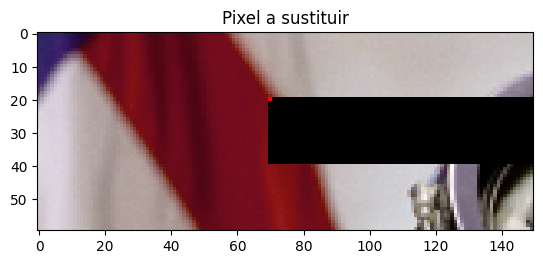

In [5]:
search_img = image_defect.copy()

pixel_to_search_x = 160
pixel_to_search_y = 70
offset = 1

search_img[pixel_to_search_x:pixel_to_search_x+offset,pixel_to_search_y:pixel_to_search_y+offset,0] = 255
search_img[pixel_to_search_x:pixel_to_search_x+offset,pixel_to_search_y:pixel_to_search_y+offset,1] = 0
search_img[pixel_to_search_x:pixel_to_search_x+offset,pixel_to_search_y:pixel_to_search_y+offset,2] = 0

plt.imshow(search_img[140:240,0:150,:])
plt.title("Pixel a sustituir")


# Miramos el template asignado al pixel y su area a buscar el mejor pixel 

Asi podemos ver en que template nos basamos y donde busca la mejor coincidencia

Area to scan shape (21, 21, 3)
Template shape (11, 11, 3)


Text(0.5, 1.0, 'Template mask ')

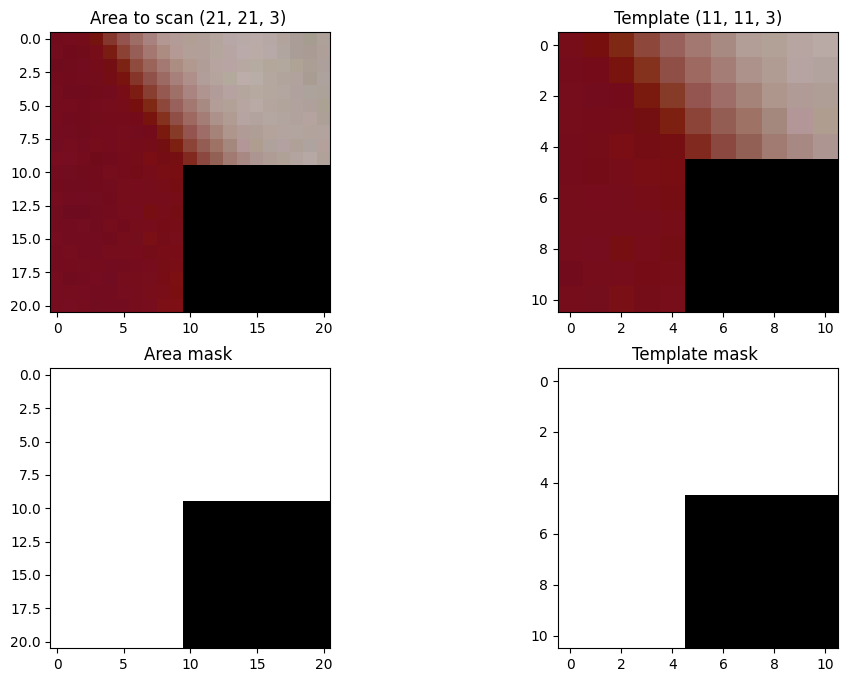

In [7]:
search_img = image_defect.copy()
known_mask = (mask == 0)  # True = píxel útil

# Pixel negro para probar el pipeline
pixel_to_search_y = 160  
pixel_to_search_x = 70

template, template_mask, area_to_scan, area_mask, hole_y_area, hole_x_area = get_template_and_area(pixel_to_search_y, pixel_to_search_x,
                          search_img, known_mask,
                          ratio_area=10, ratio_template=5)

print(f"Area to scan shape {area_to_scan.shape}")
print(f"Template shape {template.shape}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0][0].imshow(area_to_scan)
axes[0][0].set_title(f'Area to scan {area_to_scan.shape} ')

axes[0][1].imshow(template)
axes[0][1].set_title(f'Template {template.shape}')

axes[1][0].imshow(area_mask, cmap= 'gray' )
axes[1][0].set_title(f'Area mask ')

axes[1][1].imshow(template_mask , cmap= 'gray' )
axes[1][1].set_title(f'Template mask ')

# Computar SSD solo en las zonas con pixeles validos con las mascaras

Implementamos un método para calcular el SSD entre un patch y un template usando únicamente los píxeles válidos según las máscaras. De este modo evitamos que las regiones faltantes influyan en la medida de similitud, y normalizamos por el número de píxeles comparados para que la comparación sea justa aunque cambie la cantidad de información disponible.

In [8]:
def SSD_mask(patch, template, template_mask, patch_mask, eps=1e-8):
    """
    SSD entre patch y template usando SOLO píxeles donde template_mask es True.
    Se castea todo a float32 para evitar overflow de uint8.
    """
    
    patch_f    = patch.astype(np.float32)
    template_f = template.astype(np.float32)

    valid = (template_mask.astype(bool) & patch_mask.astype(bool))  # Comparar solo píxeles válidos segun la máscara
    n = int(valid.sum())
    if n == 0:
        return np.inf

    diffs = patch_f - template_f
    diffs *= valid[..., None]
    ssd = np.sum(diffs**2)

    return ssd / (n + eps)   # <-- normalizado en funcion del numero de vecinos para hacer una comparación más justa

## Buscar en toda la area de busqueda el mejor patch posible y coger su pixel central

Implementamos un método que busca el patch más similar a un template dentro de una región de búsqueda limitada. Para ello, se recorre el área de búsqueda desplazando una ventana del mismo tamaño que el template y se calcula, en cada posición, la distancia SSD considerando únicamente los píxeles válidos según las máscaras.
Durante la búsqueda, se descartan aquellos patches no válidos, como el propio template, los que tienen su píxel central dentro de una región faltante o aquellos cuyo píxel central coincide con el color del defecto. Finalmente, se selecciona el patch con el menor valor de SSD, que se considera el más similar y se utiliza para la reconstrucción del píxel objetivo.

In [10]:
def find_best_patch_v2(area_to_scan, area_mask,
                       template, template_mask,
                       hole_y_area, hole_x_area):
    """
    Busca dentro del área de búsqueda el patch más similar al template usando SSD.
    Se descartan patches no válidos (centro en defecto o el propio template) y se
    devuelve el patch con menor distancia.
    """

    template_H, template_W, _ = template.shape
    area_H, area_W, _ = area_to_scan.shape

    # esquina del template original dentro del área
    template_i0 = hole_y_area - template_H // 2
    template_j0 = hole_x_area - template_W // 2

    cy = template_H // 2
    cx = template_W // 2

    ssd_min = float('inf')
    best_patch = None
    best_i = best_j = None

    for i in range(area_H - template_H + 1):
        for j in range(area_W - template_W + 1):

            # saltar el patch que es el propio template
            if i == template_i0 and j == template_j0:
                continue

            patch      = area_to_scan[i:i+template_H, j:j+template_W]
            patch_mask = area_mask[i:i+template_H, j:j+template_W]

            # NO usar patch si su centro está en defecto
            if not patch_mask[cy, cx]:
                continue

            mask_rgb = np.array([0, 0, 0])
            # NO usar patches cuyo centro tenga el color del defecto (negro)
            center_pixel = patch[cy, cx, :]
            if np.all(center_pixel == mask_rgb):
                continue

                
            ssd = SSD_mask(patch, template, template_mask, patch_mask)

            if ssd < ssd_min:
                ssd_min = ssd
                best_patch = patch
                best_i = i
                best_j = j

    return best_patch, best_i, best_j, ssd_min

# Visualizar el resultado para el primer pixel

Area to scan shape (21, 21, 3)
Template shape (11, 11, 3)
SSD min: 40.9882352892955
best (i,j) en área: 2 3
Value best pixel:  [[[122  26  14]]]


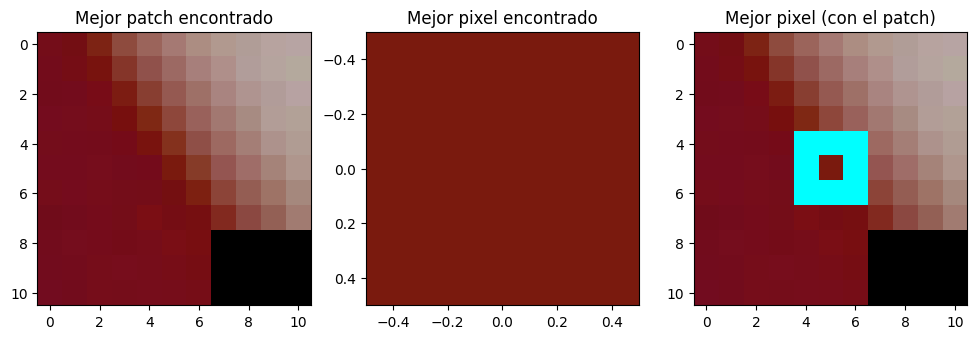

In [58]:
print(f"Area to scan shape {area_to_scan.shape}")
print(f"Template shape {template.shape}")

W,H,_= area_to_scan.shape

hole_y_area = pixel_to_search_y - W
hole_x_area = pixel_to_search_x - H

best_patch, best_i, best_j, ssd_min = find_best_patch_v2(
    area_to_scan, area_mask,
    template, template_mask,
    hole_y_area, hole_x_area
)


print("SSD min:", ssd_min)
print("best (i,j) en área:", best_i, best_j)


# PLOTS 
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(best_patch)
axes[0].set_title('Mejor patch encontrado')

template_W , template_H , _ = template.shape
cy = template_H // 2
cx = template_W // 2
print("Value best pixel: ", best_patch[cy, cx, :].reshape(1,1,3))

axes[1].imshow(best_patch[cy, cx, :].reshape(1,1,3))
axes[1].set_title('Mejor pixel encontrado')


area_best_pixel = best_patch.copy()

area_best_pixel[ cy+1, cx-1:cx+2, 0 ] = 0
area_best_pixel[ cy+1, cx-1:cx+2, 1 ] = 255
area_best_pixel[ cy+1, cx-1:cx+2, 2 ] = 255

area_best_pixel[ cy-1, cx-1:cx+2, 0 ] = 0
area_best_pixel[ cy-1, cx-1:cx+2, 1 ] = 255
area_best_pixel[ cy-1, cx-1:cx+2, 2 ] = 255

area_best_pixel[ cy, cx+1, 0 ] = 0
area_best_pixel[ cy, cx+1, 1 ] = 255
area_best_pixel[ cy, cx+1, 2 ] = 255

area_best_pixel[ cy, cx-1, 0 ] = 0
area_best_pixel[ cy, cx-1, 1 ] = 255
area_best_pixel[ cy, cx-1, 2 ] = 255

axes[2].imshow(area_best_pixel)
axes[2].set_title('Mejor pixel (con el patch)')
plt.show()

# Actualizar la imagen original con defectos

Usamos el pixel encontrado para reconstruir la imagen original

Text(0.5, 1.0, 'Imagen después de sustituir el pixel')

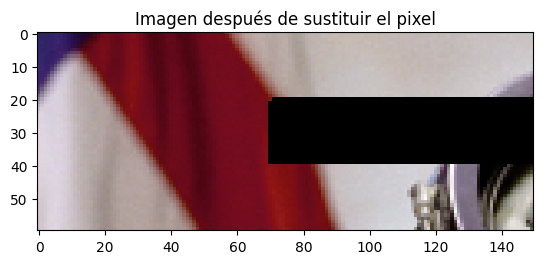

In [59]:
imagen_a_restaurar = image_defect.copy()
imagen_a_restaurar[pixel_to_search_y,pixel_to_search_x] = best_patch[cy, cx, :].reshape(1,1,3)
plt.imshow(imagen_a_restaurar[140:240,0:150,:])
plt.title("Imagen después de sustituir el pixel")


## Crear anillos para buscar los pixeles a cambiar

Una vez definido cómo reconstruir un píxel individual, es necesario determinar el orden en el que se deben rellenar los píxeles faltantes. Para ello, utilizamos la estrategia Onion Ring, que consiste en identificar anillos sucesivos alrededor de cada región faltante. En cada iteración se seleccionan los píxeles del borde del hueco, que son los que tienen más vecinos conocidos, y se rellenan de forma progresiva desde el exterior hacia el interior.

# Anillo más exterior de cada hueco de la imagen

El anillo se calcula aplicando una erosión binaria sobre la máscara del hueco. La erosión elimina los píxeles del borde de cada región defectuosa, dejando únicamente su parte interior. Al restar esta versión erosionada de la máscara original, se obtienen únicamente los píxeles más exteriores del hueco, que forman el primer anillo. Estos píxeles son los que se rellenan en la primera iteración, ya que tienen mayor número de vecinos conocidos.

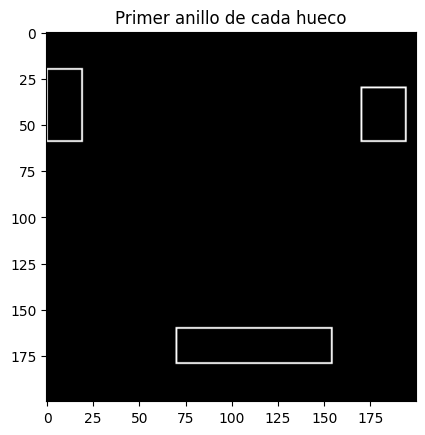

In [14]:
# Creamos un anillo con los pixeles mas exteriores
from scipy.ndimage import binary_erosion

hole_mask  = (mask == 1)    # True = defecto
known_mask = ~hole_mask
se = np.ones((3, 3), dtype=bool)

eroded = binary_erosion(hole_mask, structure=se)
ring = hole_mask & ~eroded      # píxeles a rellenar en esta “capa”

plt.imshow(ring, cmap = 'gray' )
plt.title("Primer anillo de cada hueco")
plt.show()

## Empezar con el anillo inferior

Para comprobar que el método funciona como esperamos, utilizamos solo el anillo inferior. Una vez todo funcione, aplicamos la misma lógica al resto de la imagen 

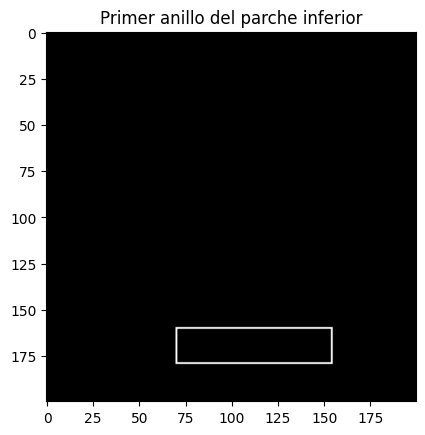

In [17]:
hole_mask  = (mask == 1)    # True = defecto
known_mask = ~hole_mask
se = np.ones((3, 3), dtype=bool)

eroded = binary_erosion(hole_mask, structure=se)
ring = hole_mask & ~eroded      # píxeles a rellenar en esta “capa”

H, W = ring.shape

ring_bottom = np.zeros_like(ring, dtype=bool)
ring_bottom[H//2+1:, :] = ring[H//2+1:, :]

original_hole_mask = hole_mask
original_known_mask = known_mask
original_ring_bottom = ring_bottom

plt.imshow(ring_bottom, cmap='gray')
plt.title("Primer anillo del parche inferior")
plt.show()

# Sustituir todo el primer anillo

Ahora que tenemos el mejor patch encontrado para 1 pixel, lo aplicamos al resto de pixeles del anillo. 

In [19]:
imagen_a_restaurar = image_defect.copy()
hole_mask = original_hole_mask.copy()
known_mask = original_known_mask.copy()


# obtener coordenadas del anillo (SOLO EL DE ABAJO)
ys, xs = np.where(ring_bottom)

# 2. Rellenar cada píxel del anillo SIN ordenar

for y, x in zip(ys, xs):
    
    template, template_mask, area_to_scan, area_mask, hole_y_area, hole_x_area = get_template_and_area(
        y, x,
        imagen_a_restaurar, known_mask
    )

    #print(f" shape template {template.shape} y kkk {kkk}")
    
    best_patch, best_i, best_j, ssd_min = find_best_patch_v2(
        area_to_scan, area_mask,
        template, template_mask,
        hole_y_area, hole_x_area
    )       
        
    cy = template.shape[0] // 2
    cx = template.shape[1] // 2
    best_pixel = best_patch[cy, cx, :]
    
    imagen_a_restaurar[y, x, :] = best_pixel

    # actualizar máscaras
    hole_mask[y, x] = False
    known_mask[y, x] = True


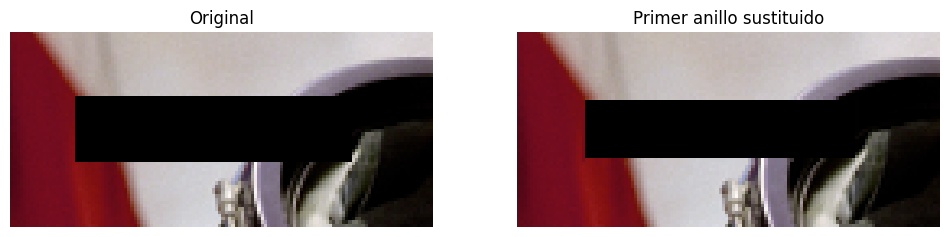

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(image_defect[140:240,50:180,:], cmap='jet')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(imagen_a_restaurar[140:240,50:180,:], cmap='jet')
axes[1].set_title('Primer anillo sustituido')
axes[1].axis('off')

plt.show()

## Conseguir todos los anillos

Para obtener todos los anillos de cada hueco, se aplica de forma iterativa una erosión binaria sobre la máscara del defecto. En cada iteración, el anillo se calcula como la diferencia entre la máscara actual y su versión erosionada, obteniendo así la capa más exterior restante. Tras extraer cada anillo, la máscara se actualiza con la imagen erosionada y el proceso se repite hasta que no quedan píxeles en el hueco. De este modo, se obtiene una secuencia ordenada de anillos desde el exterior hacia el interior, que define el orden de rellenado de los píxeles.

In [21]:
hole_mask = original_hole_mask.copy()
known_mask = original_known_mask.copy()
ring_bottom = original_ring_bottom.copy()

hole_mask_bottom = np.zeros_like(hole_mask, dtype=bool)
hole_mask_bottom[H//2:, :] = hole_mask[H//2:, :]

se = np.ones((3, 3), dtype=bool)

# Calculamos todos los anillos hacia dentro 
current = hole_mask.copy()
rings = []

while np.any(current):
    eroded = binary_erosion(current, structure=se)
    ring = current & ~eroded

    if not np.any(ring):
        break

    rings.append(ring.astype(int))
    current = eroded

print(f"Se han encontrado {len(rings)} anillos")

Se han encontrado 13 anillos


## Visualizar los anillos

Para ver los anillos de la imagen ponemos cada uno de un color del arcoiris

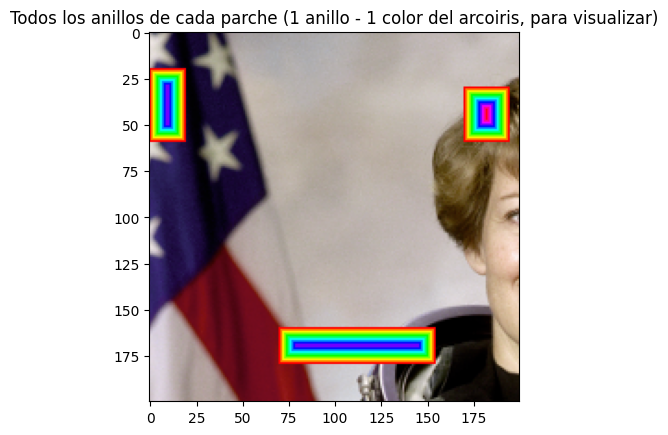

In [23]:
import matplotlib

imagen_a_restaurar = image_defect.copy()
hole_mask = original_hole_mask.copy()
known_mask = original_known_mask.copy()
ring_bottom = original_ring_bottom.copy()


cmap = matplotlib.colormaps.get_cmap('hsv')  # arcoíris continuo

for i, ring in enumerate(rings):
    # color FIJO para todo el anillo
    color = cmap(i / max(len(rings) - 1, 1))[:3]   # RGB en [0,1]
    color = (np.array(color) * 255).astype(np.uint8)

    ys, xs = np.where(ring)
    for y, x in zip(ys, xs):
        imagen_a_restaurar[y, x] = color

        
plt.imshow(imagen_a_restaurar)
plt.title("Todos los anillos de cada parche (1 anillo - 1 color del arcoiris, para visualizar)")
plt.show()

# Ahora tenemos todos los anillos , aplicamos el código anterior

Una vez hemos visto que el método funciona y que tenemos todos los anillos, aplicamos todo el algoritmo a todas las zonas faltantes

In [25]:
from scipy.ndimage import convolve
import numpy as np

hole_mask = original_hole_mask.copy()
known_mask = original_known_mask.copy()
ring_bottom = original_ring_bottom.copy()
imagen_a_restaurar = image_defect.copy()

known_mask = ~hole_mask
se = np.ones((3, 3), dtype=bool)

# Calculamos todos los anillos hacia dentro 
current = hole_mask.copy()
rings = []

while np.any(current):
    eroded = binary_erosion(current, structure=se)
    ring = current & ~eroded

    if not np.any(ring):
        break

    rings.append(ring.astype(int))
    current = eroded

print(f"Anillos calculados {len(rings)}")

Anillos calculados 13


In [26]:
import numpy as np

hole_mask = original_hole_mask.copy()
known_mask = original_known_mask.copy()
imagen_a_restaurar = image_defect.copy()

imgs, holes, known, rings_2 = [], [], [], []

kernel = np.ones((3,3), dtype=int)

for ring in rings:
    rings_2.append(ring.copy())

    ys, xs = np.where(ring)
    remaining = list(zip(ys.tolist(), xs.tolist()))

    # rellenar ESTE anillo (sin tocar el siguiente) con prioridad por vecinos
    guard = 0
    max_guard = len(remaining) * 5  # evita bucles raros si muchos "None"

    while remaining and guard < max_guard:
        guard += 1

        # vecinos conocidos (3x3) con known_mask ACTUAL
        known_neighbors = convolve(known_mask.astype(int), kernel, mode='constant', cval=0)

        # escoger el pixel del anillo con más vecinos conocidos
        best_idx = max(range(len(remaining)),
                       key=lambda k: known_neighbors[remaining[k][0], remaining[k][1]])

        y, x = remaining.pop(best_idx)

        template, template_mask, area_to_scan, area_mask, hole_y_area, hole_x_area = get_template_and_area(
            y, x, imagen_a_restaurar, known_mask
        )

        best_patch, best_i, best_j, ssd_min = find_best_patch_v2(
            area_to_scan, area_mask, template, template_mask, hole_y_area, hole_x_area
        )

        if best_patch is None:
            # aplazar para reintentar más tarde dentro del mismo anillo
            remaining.append((y, x))
            continue

        cy = template.shape[0] // 2
        cx = template.shape[1] // 2
        imagen_a_restaurar[y, x, :] = best_patch[cy, cx, :]

        hole_mask[y, x] = False
        known_mask[y, x] = True

    imgs.append(imagen_a_restaurar.copy())
    holes.append(hole_mask.copy())
    known.append(known_mask.copy())

print(f"{len(imgs)} imagenes creadas")


13 imagenes creadas


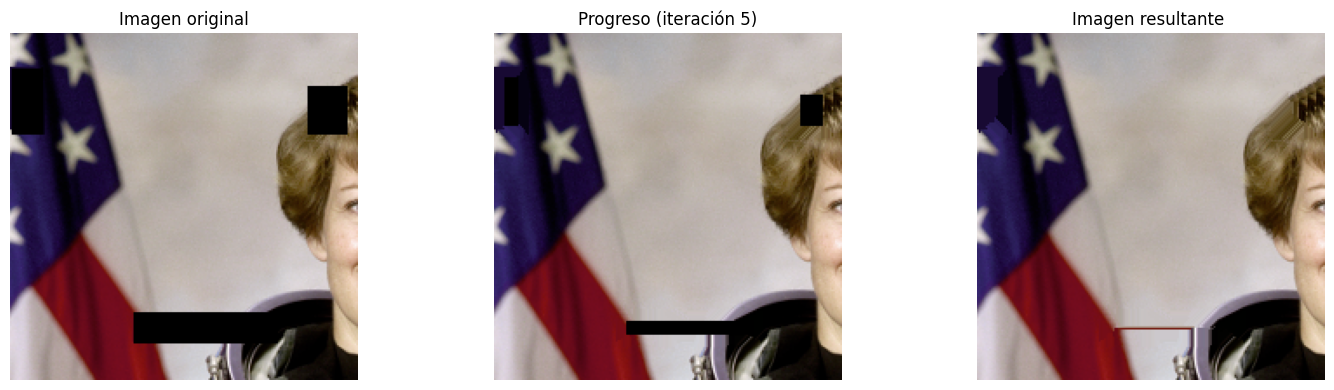

In [34]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(imgs[0])
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(imgs[5])
plt.title("Progreso (iteración 5)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(imgs[len(imgs) - 1])
plt.title("Imagen resultante ")
plt.axis("off")

plt.tight_layout()
plt.show()


# Sobre los resultados

Los resultados muestran la reconstrucción progresiva de las zonas faltantes al aplicar el algoritmo siguiendo la estrategia Onion Ring, rellenando los píxeles capa a capa. Este enfoque es coherente porque los píxeles del borde del hueco suelen tener más vecinos conocidos, lo que permite estimar su valor de forma más fiable antes de avanzar hacia el interior. De este modo, la información se propaga gradualmente desde regiones bien definidas hacia las zonas más ambiguas.

Sin embargo, en los huecos cercanos al borde de la imagen el resultado es claramente peor. En estos casos, los píxeles exteriores no disponen de suficientes vecinos válidos debido a la falta de información fuera de la imagen, lo que provoca estimaciones menos precisas y la aparición de artefactos visibles. Esto explica por qué el método funciona bien en regiones internas, pero falla de forma más acusada en zonas próximas a los límites de la imagen.

Además, es importante destacar que la aparición de imperfecciones en la imagen reconstruida es un comportamiento esperado dado el enfoque utilizado. El algoritmo implementado es una aproximación sencilla al problema de inpainting, basada en información local y en la propagación progresiva de los valores desde los bordes del hueco. La reconstrucción píxel a píxel, junto con una búsqueda de parches limitada, hace que pequeños errores se acumulen, especialmente en regiones con poca información disponible. Estas limitaciones forman parte del diseño del método y no indican un fallo en la implementación, sino las restricciones propias del algoritmo empleado.

# ONION RING PERO SIN ANILLOS

En esta sección se propone una variante del método Onion Ring. En lugar de rellenar los píxeles estrictamente capa a capa, se seleccionan en cada iteración aquellos píxeles que presentan una mayor cantidad de vecinos conocidos. Este criterio mantiene la idea original de priorizar los píxeles con más información disponible, pero permite una mayor flexibilidad en el orden de rellenado, adaptándose mejor a la forma de los huecos y a las zonas cercanas a los bordes de la imagen.

In [37]:
import numpy as np
from scipy.ndimage import convolve

def compute_front(hole_mask):
    """
    Devuelve el "frente" (borde) del agujero: píxeles del hole que tocan
    algún píxel conocido (4-vecindad). Es el onion-ring dinámico.
    """
    front = np.zeros_like(hole_mask, dtype=bool)

    front[1:, :]  |= hole_mask[1:, :]  & (~hole_mask[:-1, :])
    front[:-1, :] |= hole_mask[:-1, :] & (~hole_mask[1:, :])
    front[:, 1:]  |= hole_mask[:, 1:]  & (~hole_mask[:, :-1])
    front[:, :-1] |= hole_mask[:, :-1] & (~hole_mask[:, 1:])

    return front


# -------------------------
# ONION RING "SIN ANILLOS"
# (siempre elijo el píxel del frente con más vecinos conocidos)
# -------------------------
hole_mask = original_hole_mask.copy()
known_mask = original_known_mask.copy()
imagen_a_restaurar = image_defect.copy()

imgs, holes, knowns, fronts = [], [], [], []   # mismo estilo que antes
kernel = np.ones((3,3), dtype=int)

# guardarraíles
max_iters = int(hole_mask.sum()) * 10
iters = 0

while hole_mask.any() and iters < max_iters:
    iters += 1

    # calcular frente actual
    front = compute_front(hole_mask)
    fronts.append(front.astype(int))

    ys, xs = np.where(front)
    if len(ys) == 0:
        # agujero raro / máscara inconsistente
        break

    # lista de candidatos (píxeles del frente)
    remaining = list(zip(ys.tolist(), xs.tolist()))

    # rellenar UN píxel por iteración (el de más vecinos conocidos)
    #    con reintentos si no hay patch válido
    guard = 0
    max_guard = len(remaining) * 5

    filled = False
    while remaining and guard < max_guard and not filled:
        guard += 1

        # Primero contamos cuantos vecinos conocidos hay
        known_neighbors = convolve(known_mask.astype(int), kernel, mode='constant', cval=0)

        # Selecciona el mejor candidato a rellenar
        best_idx = max(
            range(len(remaining)),
            key=lambda k: known_neighbors[remaining[k][0], remaining[k][1]]
        )

        y, x = remaining.pop(best_idx)

        template, template_mask, area_to_scan, area_mask, hole_y_area, hole_x_area = get_template_and_area(
            y, x, imagen_a_restaurar, known_mask
        )

        best_patch, best_i, best_j, ssd_min = find_best_patch_v2(
            area_to_scan, area_mask, template, template_mask, hole_y_area, hole_x_area
        )

        if best_patch is None:
            # reintentar otro candidato del frente (o reintentar más tarde)
            continue

        cy = template.shape[0] // 2
        cx = template.shape[1] // 2
        imagen_a_restaurar[y, x, :] = best_patch[cy, cx, :]

        hole_mask[y, x] = False
        known_mask[y, x] = True
        filled = True

    # guardar estado como antes (progreso)
    imgs.append(imagen_a_restaurar.copy())
    holes.append(hole_mask.copy())
    knowns.append(known_mask.copy())

print(f"{len(imgs)} imagenes creadas | iters={iters} | hole remaining={int(hole_mask.sum())}")


3250 imagenes creadas | iters=3250 | hole remaining=0


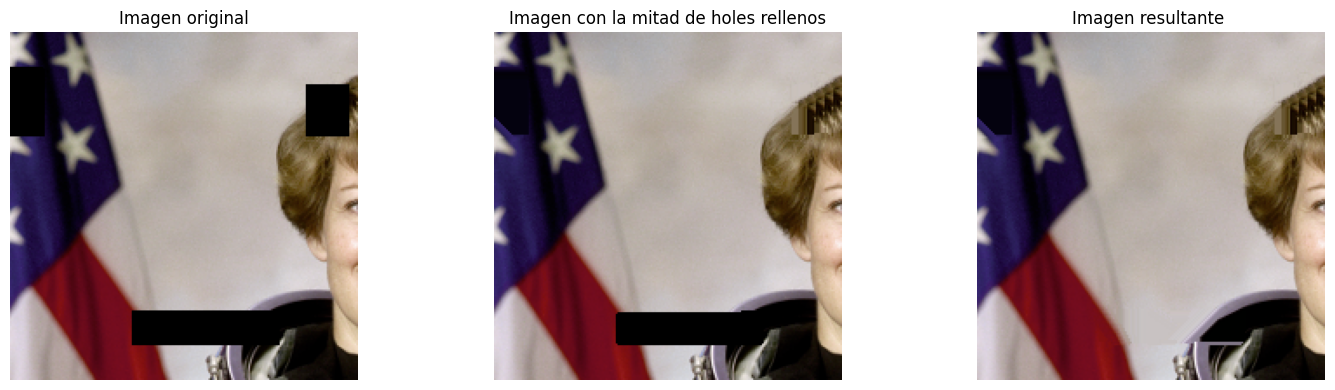

In [40]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(imgs[0])
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(imgs[len(imgs) // 2])
plt.title("Imagen con la mitad de holes rellenos")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(imgs[len(imgs) - 1])
plt.title("Imagen resultante ")
plt.axis("off")
    
plt.tight_layout()
plt.show()


# Sobre los nuevos resultados

Los resultados obtenidos muestran que la estrategia basada en seleccionar, en cada iteración, el píxel con mayor número de vecinos conocidos permite una reconstrucción progresiva y coherente de las regiones faltantes. En la imagen intermedia se aprecia cómo los huecos se van cerrando de forma gradual, manteniendo en general la continuidad de colores y estructuras cercanas, lo que indica que priorizar la información disponible es un criterio razonable.

No obstante, al igual que en el método anterior, el resultado final presenta ciertas imperfecciones, especialmente en zonas con pocos vecinos o cercanas a los bordes de la imagen. Aunque este enfoque es más flexible que el Onion Ring estricto y se adapta mejor a la geometría del hueco, sigue estando limitado por la información local y por la acumulación de pequeños errores durante el rellenado. En conjunto, los resultados son coherentes con el diseño del algoritmo y reflejan tanto sus ventajas como sus limitaciones inherentes.

# Mejorar el resultado mediante Gradient-based filling

El Gradient-based filling se basa en priorizar el rellenado de píxeles siguiendo la dirección y continuidad de los gradientes de la imagen, de modo que se preserven mejor bordes y estructuras. En lugar de basarse solo en similitud de parches, el método utiliza la información de gradiente para propagar correctamente contornos y transiciones de intensidad dentro de las regiones faltantes.

## Metodos auxiliares para aplicar le metodo

Este conjunto de funciones sirve para mejorar el criterio de prioridad al rellenar los píxeles, incorporando información de estructura y bordes de la imagen.
La confianza mide cuánta información válida rodea a un píxel, mientras que el término de gradiente favorece la propagación de contornos siguiendo la dirección de los bordes, permitiendo que el relleno preserve mejor las estructuras importantes de la imagen.

In [43]:
def confidence_C(y, x, imagen, known_mask):
    """
    Confianza C(p): proporción de píxeles conocidos dentro del template.
    Devuelve un valor en [0,1].
    """
    template, template_mask, _, _, _, _ = get_template_and_area(
        y, x, imagen, known_mask
    )
    return float(template_mask.mean())

def to_gray(imagen):
    """RGB -> grayscale float32."""
    img = imagen.astype(np.float32)
    return 0.299*img[...,0] + 0.587*img[...,1] + 0.114*img[...,2]

def front_normal_from_knownmask(known_mask, y, x, eps=1e-6):
    H, W = known_mask.shape
    ym1 = max(0, y-1); yp1 = min(H-1, y+1)
    xm1 = max(0, x-1); xp1 = min(W-1, x+1)

    dky = float(known_mask[yp1, x]) - float(known_mask[ym1, x])
    dkx = float(known_mask[y, xp1]) - float(known_mask[y, xm1])

    ny, nx = dky, dkx
    nrm = (ny*ny + nx*nx)**0.5 + eps
    return ny/nrm, nx/nrm


def image_gradient(gray, y, x):
    """Gradiente centrado simple en (y,x)."""
    H, W = gray.shape
    ym1 = max(0, y-1); yp1 = min(H-1, y+1)
    xm1 = max(0, x-1); xp1 = min(W-1, x+1)

    gy = float(gray[yp1, x]) - float(gray[ym1, x])
    gx = float(gray[y, xp1]) - float(gray[y, xm1])
    return gy, gx

def gradient_term_D(y, x, imagen, known_mask, alpha=255.0):
    """
    Data term D(p): magnitud de la isófota proyectada sobre la normal del frente.
    Devuelve un valor >=0 (típicamente ~[0,1]).
    
    También devuelve (ny,nx) y (iy,ix) para que puedas visualizar flechas si quieres.
    """
    gray = to_gray(imagen)

    # normal del frente (desde known_mask, NO hole_mask)
    ny, nx = front_normal_from_knownmask(known_mask, y, x)

    # gradiente de imagen
    gy, gx = image_gradient(gray, y, x)

    # isófota = grad rotado 90º
    iy, ix = -gy, gx

    D = abs(iy*ny + ix*nx) / alpha
    return float(D), (ny, nx), (iy, ix)


# Ver el problema inicial

Text(0.5, 1.0, 'known_mask (200, 200)')

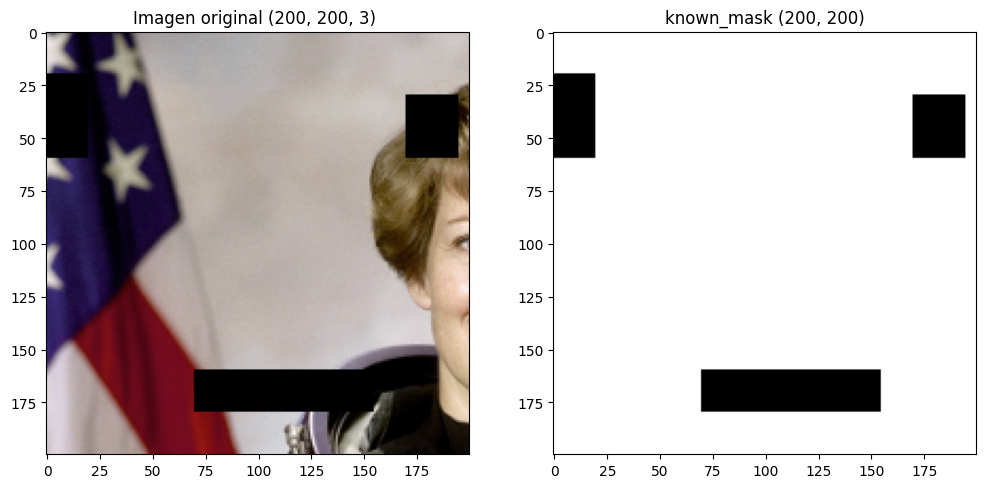

In [46]:
imagen_a_restaurar = image_defect.copy()
known_mask = (mask == 0)  # True = píxel útil

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].imshow(imagen_a_restaurar)
axes[0].set_title(f'Imagen original {imagen_a_restaurar.shape} ')

axes[1].imshow(known_mask, cmap='gray')
axes[1].set_title(f'known_mask {known_mask.shape}')

# Volver a empezar con 1 pixel para entender que hace el método

Area to scan shape (21, 21, 3)
Template shape (11, 11, 3)


Text(0.5, 1.0, 'Template (11, 11, 3)')

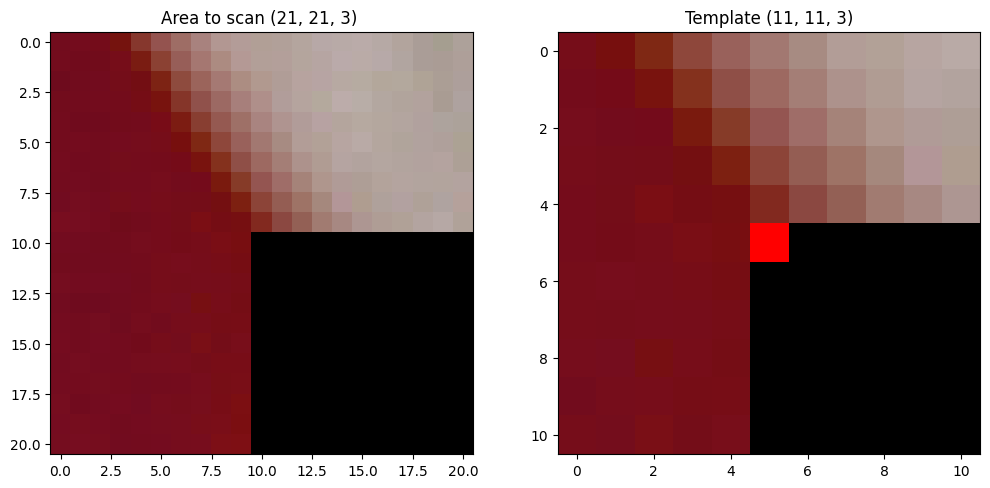

In [49]:
search_img = image_defect.copy()
known_mask = (mask == 0)  # True = píxel útil

# Pixel negro para probar el pipeline
pixel_to_search_y = 160  
pixel_to_search_x = 70

template, template_mask, area_to_scan, area_mask, hole_y_area, hole_x_area = get_template_and_area(pixel_to_search_y, pixel_to_search_x,
                          search_img, known_mask,
                          ratio_area=10, ratio_template=5)

print(f"Area to scan shape {area_to_scan.shape}")
print(f"Template shape {template.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].imshow(area_to_scan)
axes[0].set_title(f'Area to scan {area_to_scan.shape} ')

template[5,5,:] = [255,0,0]

axes[1].imshow(template)
axes[1].set_title(f'Template {template.shape}')


In [50]:
pixel_to_search_y = 160
pixel_to_search_x = 70

C = confidence_C(pixel_to_search_y, pixel_to_search_x, imagen_a_restaurar, known_mask)
D, n, iso = gradient_term_D(pixel_to_search_y, pixel_to_search_x, imagen_a_restaurar, known_mask)

print("C:", C, "D:", D, "normal:", n, "isofota:", iso)


C: 0.7024793388429752 D: 0.05666556010634128 normal: (-0.7071062811869011, -0.7071062811869011) isofota: (66.47100067138672, -46.0359992980957)


Estos valores indican que el píxel seleccionado tiene bastante información conocida alrededor (C ≈ 0.70), por lo que es un buen candidato para ser rellenado. El término de gradiente es pequeño (D ≈ 0.056), lo que sugiere que en esa zona no hay un borde muy marcado que deba propagarse con prioridad. La normal del frente indica la dirección en la que avanza el relleno, mientras que la isófota refleja la dirección del cambio de intensidad en la imagen, información que se utiliza para preservar la estructura cuando hay bordes relevantes.

In [52]:
def compute_front(hole_mask, known_mask):
    """
    Devuelve máscara booleana de píxeles del agujero (hole_mask=True)
    que tienen al menos un vecino conocido (4-conectado).
    """
    front = np.zeros_like(hole_mask, dtype=bool)

    # vecino arriba conocido
    front[1:, :]  |= hole_mask[1:, :]  & known_mask[:-1, :]
    # vecino abajo conocido
    front[:-1, :] |= hole_mask[:-1, :] & known_mask[1:, :]
    # vecino izquierda conocido
    front[:, 1:]  |= hole_mask[:, 1:]  & known_mask[:, :-1]
    # vecino derecha conocido
    front[:, :-1] |= hole_mask[:, :-1] & known_mask[:, 1:]

    return front

In [53]:
import numpy as np
from scipy.ndimage import convolve

hole_mask = original_hole_mask.copy()
known_mask = original_known_mask.copy()
imagen_a_restaurar = image_defect.copy()

imgs, holes, knowns, fronts = [], [], [], []

kernel = np.ones((3,3), dtype=int)
alpha = 255.0

guard = 0
max_guard = int(hole_mask.sum()) * 10

while hole_mask.any() and guard < max_guard:
    guard += 1

    # 1) frente actual (onion ring dinámico)
    front = compute_front(hole_mask, known_mask)
    fronts.append(front.astype(int))

    ys, xs = np.where(front)
    if len(ys) == 0:
        break

    front_coords = list(zip(ys.tolist(), xs.tolist()))

    # 2) prioridad: vecinos conocidos + gradiente (C * D)
    known_neighbors = convolve(known_mask.astype(int), kernel, mode='constant', cval=0)

    best_score = -np.inf
    best_pixel = None

    for y, x in front_coords:
        C = confidence_C(y, x, imagen_a_restaurar, known_mask)
        D, _, _ = gradient_term_D(y, x, imagen_a_restaurar, known_mask, alpha=alpha)
        score = known_neighbors[y, x] * C * D

        if score > best_score:
            best_score = score
            best_pixel = (y, x)

    if best_pixel is None:
        break

    y, x = best_pixel

    # 3) rellenar píxel a píxel:
    #    copiamos el valor medio de los vecinos conocidos (3x3)
    ys_n = slice(max(0, y-1), y+2)
    xs_n = slice(max(0, x-1), x+2)

    neighbors = imagen_a_restaurar[ys_n, xs_n]
    mask_n    = known_mask[ys_n, xs_n]

    if not mask_n.any():
        continue

    imagen_a_restaurar[y, x, :] = neighbors[mask_n].mean(axis=0)

    hole_mask[y, x] = False
    known_mask[y, x] = True

    # guardar estado (progreso)
    imgs.append(imagen_a_restaurar.copy())
    holes.append(hole_mask.copy())
    knowns.append(known_mask.copy())

print(f"{len(imgs)} imagenes creadas | hole remaining: {int(hole_mask.sum())}")


3250 imagenes creadas | hole remaining: 0


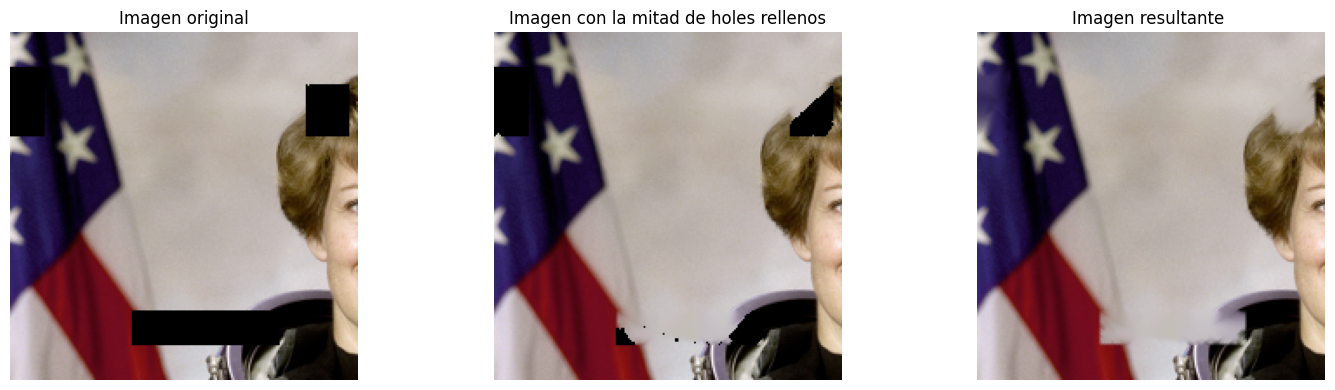

In [54]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(imgs[0])
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(imgs[len(imgs) // 2])
plt.title("Imagen con la mitad de holes rellenos")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(imgs[len(imgs) - 1])
plt.title("Imagen resultante ")
plt.axis("off")

plt.tight_layout()
plt.show()


# Sobre los resultados obtenidos

El rellenado basado en gradientes prioriza la propagación de estructuras y contornos siguiendo la dirección de los cambios de intensidad de la imagen. Esto permite preservar bordes relevantes, pero también hace que el método sea muy sensible a errores locales, especialmente cuando la información disponible es limitada o cuando los gradientes no están bien definidos. Como consecuencia, pueden aparecer artefactos visibles o zonas con reconstrucciones irregulares, como se observa en la imagen intermedia y en el resultado final.

En la zona de la bandera hay bordes y gradientes bien definidos, lo que permite al método gradient-based propagar correctamente la estructura y mantener la continuidad de las formas. Sin embargo, en otras regiones —especialmente en zonas más homogéneas o con menos contraste— los gradientes son débiles o ambiguos, y el algoritmo tiende a propagar información del fondo en lugar de preservar la estructura del objeto principal.

Esto provoca que pequeños errores iniciales se amplifiquen a medida que avanza el rellenado, dando prioridad a regiones con gradientes más estables (como el fondo) frente a aquellas con menos información estructural clara, lo que explica el resultado observado.

Además, este método resulta más lento que las estrategias anteriores, ya que en cada iteración es necesario calcular gradientes, normales y criterios de prioridad para decidir qué píxel rellenar a continuación. Aunque el enfoque es conceptualmente más avanzado y adecuado para preservar estructuras, sus resultados en esta práctica están limitados por el uso de información local y por el relleno píxel a píxel, lo que explica tanto la degradación visual en algunas zonas como el mayor coste computacional.